In [1]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import dates as mdates
from scipy import stats

In [10]:
tick_csv: str = "20260408_9984.csv"
dir_log = "logs_20260408_3"
counter = "000099"

100000000.0

## ティックデータ

In [9]:
df_tick = pd.read_csv(tick_csv)
df_tick.index = [datetime.datetime.fromtimestamp(t) for t in df_tick["Time"]]
df_tick.index.name = "Datetime"
#list_name = ["Time","Price","Volume"]
#tuple(df_tick.iloc[0][list_name])
df_tick

(1775606906.00443, 3770.0, 2865200.0)

## Rewards

In [10]:
log_reward = os.path.join(dir_log, f"reward_{counter}.csv")
df_reward = pd.read_csv(log_reward)
df_reward.sort_values("ts")
df_reward.index = [pd.Timestamp.fromtimestamp(t) for t in df_reward["ts"]]
df_reward["cumsum"] = df_reward["reward"].cumsum()
df_reward = df_reward.sort_index()
df_reward

,ts,reward,cumsum
2026-04-08 09:08:26.004430,1.775607e+09,-1.00,-1.000000
2026-04-08 09:08:28.011920,1.775607e+09,-0.10,-1.100000
2026-04-08 09:08:30.019670,1.775607e+09,-0.02,-1.120000
2026-04-08 09:08:32.042150,1.775607e+09,-0.02,-1.140000
2026-04-08 09:08:34.063500,1.775607e+09,0.00,-1.140000
...,...,...,...
2026-04-08 15:24:38.251240,1.775629e+09,-0.04,-870.459898
2026-04-08 15:24:40.252690,1.775629e+09,-0.04,-870.499898
2026-04-08 15:24:42.255710,1.775629e+09,-0.06,-870.559898
2026-04-08 15:24:44.263680,1.775629e+09,-0.06,-870.619898


## Transaction

In [5]:
log_transaction = os.path.join(dir_log, f"transaction_{counter}.csv")
df_transaction = pd.read_csv(log_transaction)
n_contract = len(df_transaction)
df_profit = df_transaction[df_transaction["売買"].isin(["買埋", "売埋"])]
df_profit["累積損益"] = df_profit["損益"].cumsum()
df_profit.index = [pd.to_datetime(s) for s in df_profit["注文日時"]]
df_profit

,注文番号,注文日時,銘柄コード,売買,約定単価,約定数量,損益,備考,累積損益
2026-04-08 09:08:52.136280060,2,2026-04-08 09:08:52.136280060,9984,売埋,3777.0,1,7.0,NaN,7.0
2026-04-08 09:23:00.726419926,4,2026-04-08 09:23:00.726419926,9984,売埋,3775.0,1,-2.0,NaN,5.0
2026-04-08 09:23:12.772300005,6,2026-04-08 09:23:12.772300005,9984,売埋,3776.0,1,2.0,NaN,7.0
2026-04-08 09:26:27.499350071,8,2026-04-08 09:26:27.499350071,9984,売埋,3784.0,1,6.0,NaN,13.0
2026-04-08 11:09:44.140549898,10,2026-04-08 11:09:44.140549898,9984,売埋,3796.0,1,12.0,NaN,25.0
2026-04-08 12:30:04.406189919,12,2026-04-08 12:30:04.406189919,9984,売埋,3828.0,1,31.0,NaN,56.0
2026-04-08 13:03:24.078579903,14,2026-04-08 13:03:24.078579903,9984,売埋,3833.0,1,14.0,NaN,70.0
2026-04-08 13:04:20.188220024,16,2026-04-08 13:04:20.188220024,9984,売埋,3851.0,1,19.0,NaN,89.0
2026-04-08 13:04:28.210220098,18,2026-04-08 13:04:28.210220098,9984,買埋,3849.0,1,1.0,NaN,90.0
2026-04-08 13:04:46.313560009,20,2026-04-08 13:04:46.313560009,9984,買埋,3843.0,1,4.0,NaN,94.0


logs_20260408_3/review_000099.png


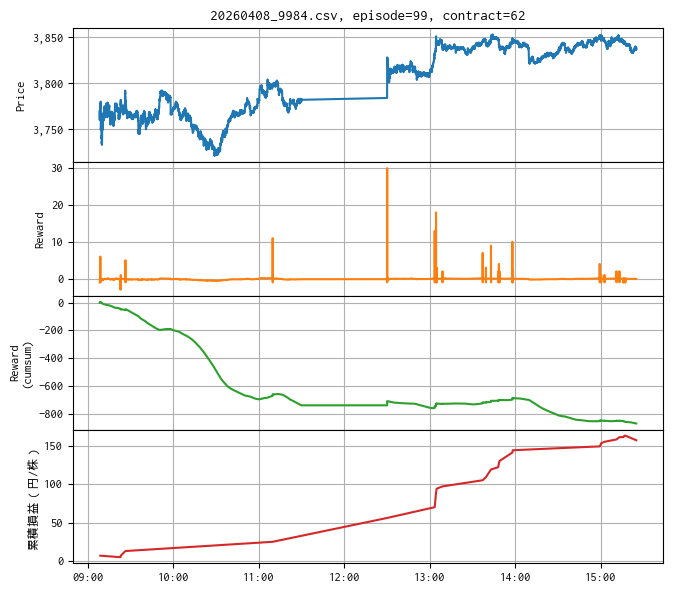

In [6]:
FONT_PATH = "fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig = plt.figure(figsize=(6.8, 6))
ax = dict()
n = 4
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[1 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

gtitle = f"{tick_csv}, episode={int(counter)}, contract={n_contract:,d}"
ax[0].set_title(gtitle)
ax[0].plot(df_tick["Price"], color="C0")
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].set_ylabel("Price")
# ax[0].legend(loc="upper left", fontsize=7)

ax[1].plot(df_reward["reward"], color="C1")
ax[1].set_ylabel("Reward")

ax[2].plot(df_reward["cumsum"], color="C2")
ax[2].set_ylabel("Reward\n(cumsum)")

ax[3].plot(df_profit["累積損益"], color="C3")
ax[3].set_ylabel("累積損益（円/株）")

plt.tight_layout()
img_review = os.path.join(dir_log, f"review_{counter}.png")
print(img_review)
plt.savefig(img_review)
plt.show()